# Testing the Effectiveness of a Campaign on Questionnaire Responsiveness

In [152]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

In [119]:
# Upoad data
df = pd.read_csv("AdSmartABdata - AdSmartABdata.csv")

# Preliminary analysis

In [7]:
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [6]:
df.describe()

,hour,platform_os,yes,no
count,8077.000000,8077.000000,8077.000000,8077.000000
mean,11.615080,5.947134,0.070818,0.083075
std,5.734879,0.224333,0.256537,0.276013
min,0.000000,5.000000,0.000000,0.000000
25%,7.000000,6.000000,0.000000,0.000000
50%,13.000000,6.000000,0.000000,0.000000
75%,15.000000,6.000000,0.000000,0.000000
max,23.000000,7.000000,1.000000,1.000000


In [118]:
# Missing data
df[df.isnull().any(axis=1)]

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no,dummy_experment,dummy_experiment


In [198]:
# Coarsen multi-category data 
df['device_make'] = df['device_make'].str.split().str[0]

In [200]:
df['time_of_day'] = pd.cut(df['hour'],
    bins=[0,6,12,18,24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=False
)

# Balanced data check

## Group sizes

In [39]:
df['experiment'].value_counts()

experiment
control    4071
exposed    4006
Name: count, dtype: int64

## Resposes over time

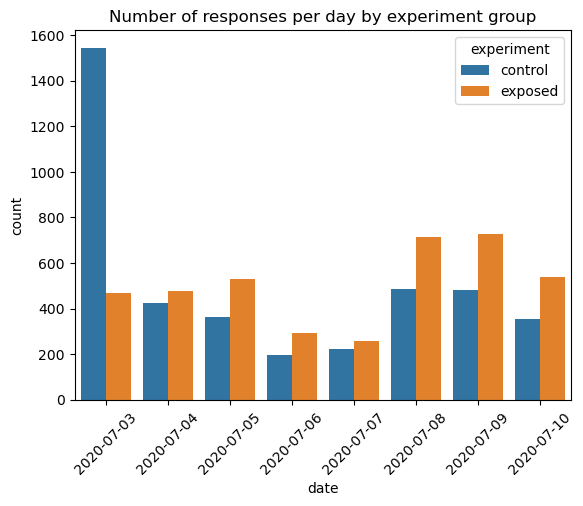

In [65]:
daily_counts = df.groupby(['date', 'experiment']).size().reset_index(name='count')
sns.barplot(daily_counts, x='date', y='count', hue = 'experiment')
plt.title("Number of responses per day by experiment group")
plt.xticks(rotation = 45)
plt.show()

## Browsers used across the groups

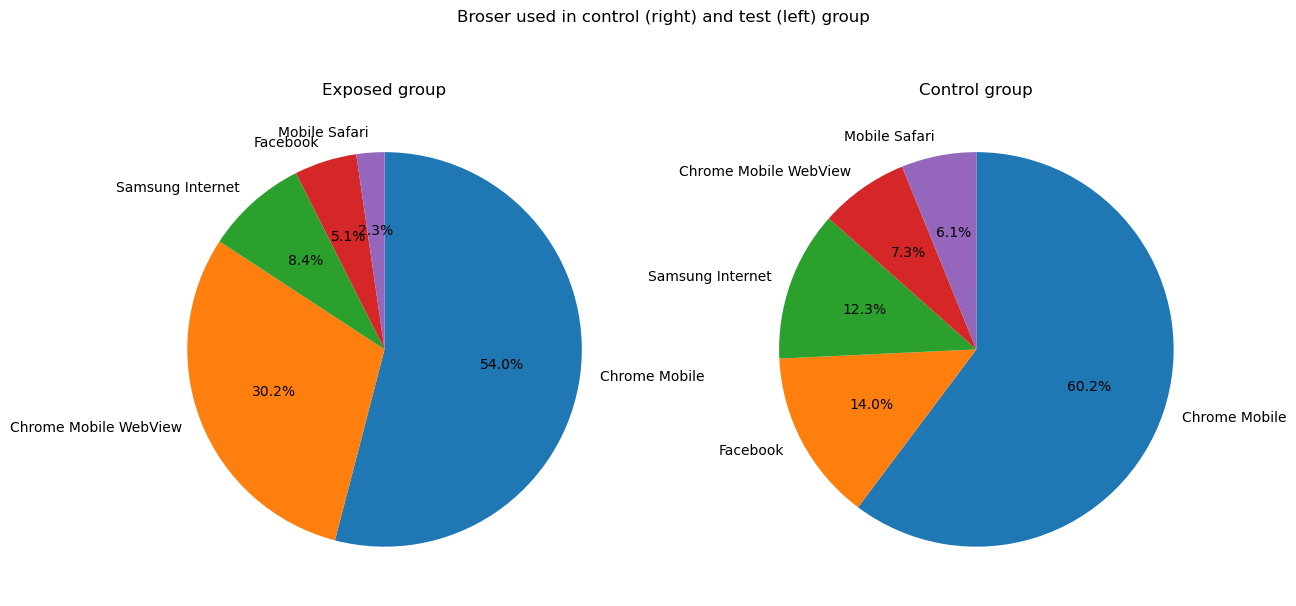

In [146]:
# Dummy Variable for 'experiment'
df['dummy_experiment'] = np.where(df['experiment'] == 'exposed', 1, 0)
# Control

exposed = df[df['dummy_experiment'] ==1].copy()
exposed_browser_types_c = exposed['browser'].value_counts().nlargest(5)
control = df[df['dummy_experiment'] ==0].copy()
colntrol_browser_types_c = control['browser'].value_counts().nlargest(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))
fig.suptitle('Broser used in control (right) and test (left) group')
ax1.pie(exposed_browser_types_c,
        labels=exposed_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
       )
ax1.set_title('Exposed group')
ax2.pie(colntrol_browser_types_c,
        labels=colntrol_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False)
ax2.set_title('Control group')
plt.show()

The groups are balanced as both of them have almost identical sample size.
The browsers used across the both groups are also roughly similar. The strongly unbalanced day (2020-07-03) might invalidate your A/B test, but we should check why it’s unbalanced. Adjustment for the biases is needed.

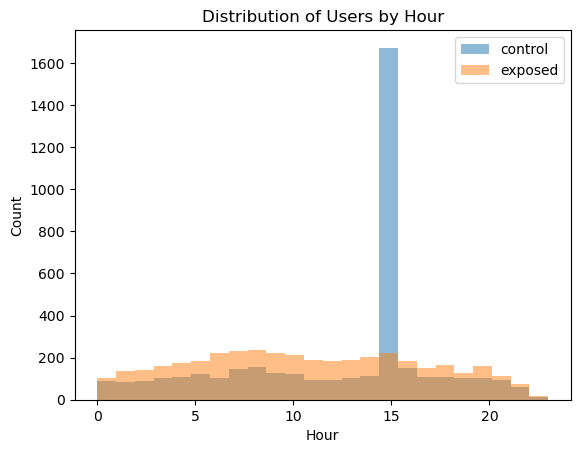

In [228]:
df.groupby('experiment')['hour'].value_counts(normalize=True)['control']
plt.hist(df[df['experiment'] == 'control']['hour'], bins=24, alpha=0.5, label='control')
plt.hist(df[df['experiment'] == 'exposed']['hour'], bins=24, alpha=0.5, label='exposed')
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title('Distribution of Users by Hour')
plt.legend()
plt.show()

In [240]:
df.groupby(['experiment'])['platform_os'].value_counts()

experiment  platform_os
control     6              3763
            5               308
exposed     6              3885
            5               120
            7                 1
Name: count, dtype: int64

Moreover, the assignment the the groups in is also biased with respect to the hour. Most exposed users are on platform 6 (97%),
while control users are slightly more mixed (only 92% on platform 6, and 7.5% on platform 5).

In [241]:
contingency = pd.crosstab(df['experiment'], df['platform_os'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")

Chi² = 85.008, p-value = 3.4734e-19


# Hypothesis
H0: mu_0 >= mu_1

H1: mu_0 < mu_1

Assuming randomners at the group assignment, this hypotheseis specifies one-sided alternative hypothesis, which tests that the mean number of 'yes' responses is greater in the exposed group than in the control group. The sample sizes are big, and populaiton standard deviartion is unknown, therefor t-statictic will be applied. We assume 95% confidence interval, which corresponds to 0.05 confidence level (allowable rate of false positives).

In [132]:
contorol_conversion = np.where((control['yes'] + control['no']) == 0, 0, control['yes'] / (control['yes'] + control['no']))

exposed_conversion = np.where((exposed['yes']+exposed['no'])==0,0,exposed['yes']/(exposed['yes']+exposed['no']))


In [232]:
from scipy import stats
t_stat, p_val = ttest_ind(contorol_conversion, exposed_conversion, alternative = 'greater')

In [151]:
print(f"P-value for the number of 'yes': {np.round(p_val,3)}")

P-value for the number of 'yes': 0.982


The lack of signifficant increase in the number of 'yes' selections suggests no substantial gain in the number of clients.

# Causal Inference
The analysis of the imbalance in the assignment of users to different groups has show that random sapling has been compromised and it needs to be taken into account as a confounder. Additionaly other response predictors will be added to the model to improve its precision. Here we pose the question "What is the causal effect of showing the ad on the probability that a user says ‘yes’?"

In [235]:
model = smf.logit('yes ~ C(experiment) + C(date) + C(time_of_day)', data = df).fit()
model_1 = smf.logit('yes ~ C(experiment) + C(date) + C(time_of_day)+ C(platform_os)', data = df).fit()

Optimization terminated successfully.
         Current function value: 0.254591
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.252551
         Iterations 26


In [234]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8077
Model:                          Logit   Df Residuals:                     8063
Method:                           MLE   Df Model:                           13
Date:                Wed, 05 Nov 2025   Pseudo R-squ.:                 0.01251
Time:                        23:47:17   Log-Likelihood:                -2039.9
converged:                       True   LL-Null:                       -2065.7
Covariance Type:            nonrobust   LLR p-value:                 1.530e-06
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -4.4354      0.473     -9.382      0.000      -5.362      -3.509
C(experiment)[T.exposed]        0.1652      0.094      1.764      0.078      -0.018       0.349
C(date)[T.2020-07-04]           0.0365      0.159      0.230      0.818      -0.275       0.348
C(date)[T.2020-07-05]          -0.3757      0.178     -2.114      0.035      -0.724      -0.027
C(date)[T.2020-07-06]          -0.1374      0.215     -0.640      0.522      -0.558       0.283
C(date)[T.2020-07-07]          -0.0585      0.200     -0.293      0.770      -0.450       0.333
C(date)[T.2020-07-08]          -0.2283      0.160     -1.429      0.153      -0.541       0.085
C(date)[T.2020-07-09]          -0.1928      0.155     -1.246      0.213      -0.496       0.110
C(date)[T.2020-07-10]          -0.2946      0.174     -1.693      0.090      -0.636       0.046
C(time_of_day)[T.morning]       0.1529      0.135      1.130      0.258      -0.112       0.418
C(time_of_day)[T.afternoon]     0.0201      0.140      0.143      0.886      -0.255       0.295
C(time_of_day)[T.evening]       0.3202      0.162      1.976      0.048       0.003       0.638
C(platform_os)[T.6]             1.8652      0.453      4.122      0.000       0.978       2.752
C(platform_os)[T.7]           -29.2608   1.89e+07  -1.55e-06      1.000   -3.71e+07    3.71e+07
===============================================================================================
"""

In [236]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8077
Model:                          Logit   Df Residuals:                     8063
Method:                           MLE   Df Model:                           13
Date:                Wed, 05 Nov 2025   Pseudo R-squ.:                 0.01251
Time:                        23:51:09   Log-Likelihood:                -2039.9
converged:                       True   LL-Null:                       -2065.7
Covariance Type:            nonrobust   LLR p-value:                 1.530e-06
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -4.4354      0.473     -9.382      0.000      -5.362      -3.509
C(experiment)[T.exposed]        0.1652      0.094      1.764      0.078      -0.018       0.349
C(date)[T.2020-07-04]           0.0365      0.159      0.230      0.818      -0.275       0.348
C(date)[T.2020-07-05]          -0.3757      0.178     -2.114      0.035      -0.724      -0.027
C(date)[T.2020-07-06]          -0.1374      0.215     -0.640      0.522      -0.558       0.283
C(date)[T.2020-07-07]          -0.0585      0.200     -0.293      0.770      -0.450       0.333
C(date)[T.2020-07-08]          -0.2283      0.160     -1.429      0.153      -0.541       0.085
C(date)[T.2020-07-09]          -0.1928      0.155     -1.246      0.213      -0.496       0.110
C(date)[T.2020-07-10]          -0.2946      0.174     -1.693      0.090      -0.636       0.046
C(time_of_day)[T.morning]       0.1529      0.135      1.130      0.258      -0.112       0.418
C(time_of_day)[T.afternoon]     0.0201      0.140      0.143      0.886      -0.255       0.295
C(time_of_day)[T.evening]       0.3202      0.162      1.976      0.048       0.003       0.638
C(platform_os)[T.6]             1.8652      0.453      4.122      0.000       0.978       2.752
C(platform_os)[T.7]           -29.2608   1.89e+07  -1.55e-06      1.000   -3.71e+07    3.71e+07
===============================================================================================
"""

When controlling only for date and time of day, exposure to the new ad is associated with a statistically significant increase in the likelihood of responding “yes” (+0.23, p < 0.05). This effect is statistically significant when no additional variables are considered. 
However, after accounting for platform differences, the effect becomes statistically insignificant, suggesting that variation in operating systems may partly explain the observed difference between groups.
Therefore, while the results provide initial evidence of a potential positive effect, they do not conclusively establish a causal impact of the new ad.
It is recommended to conduct a follow-up experiment with better balancing across device types and time slots, and possibly a larger sample size, to validate these findings before making strategic decisions about wider campaign implementation.